In [2]:
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append('../') 
from visualisation import *
from epd_process_funcs import *

In [23]:
solar=pd.read_csv('/home/hossein/CICCADA/BOM_NCI/2022/NCI_processed_grouped_Nov.csv')
solar['time'] = pd.to_datetime(solar['time'])
solar['time'] = solar['time'].dt.tz_localize('utc')
solar['time'] = solar['time'].dt.tz_convert(pytz.FixedOffset(9.5*60))
solar['postcode'] = solar['postcode'].astype(int)
solar.rename(columns={'surface_global_irradiance': 'GHI', 'direct_normal_irradiance': 'DNI'}, inplace=True)

In [4]:
5068 in solar['postcode'].unique()

True

In [5]:
edp_path = "4) Data/EDP SA 2023 Data"
df = pd.read_csv('edp_data_2022_11_v.csv')

In [6]:
meta_data1= pd.read_csv(edp_path+"/edp_sites_metadata_sa_postcode.csv")
meta_data2 = pd.read_csv(edp_path+"/edp_sites_metadata59239829.csv")
meta_data2 = meta_data2[meta_data2['state'] == 'SA']
meta_data3 = meta_data2.merge(meta_data1[['edp_site_id', 'postcode']], on='edp_site_id', how='left')
meta_data3['Srated'] = meta_data3['inverter_ac_rating_kw']*meta_data3['inverter_count']
meta_data3['Srated'] = meta_data3.apply(lambda row: row['inverter_ac_rating_kw'] if pd.isna(row['inverter_count']) else row['Srated'], axis=1)
meta_data2 = meta_data3.groupby(['edp_site_id', 'postcode']).agg({'Srated':'sum'}).reset_index()

In [43]:
df5 = process_edp(df, meta_data2, 10.5*60)


In [44]:
ii=0

In [95]:
ii

0

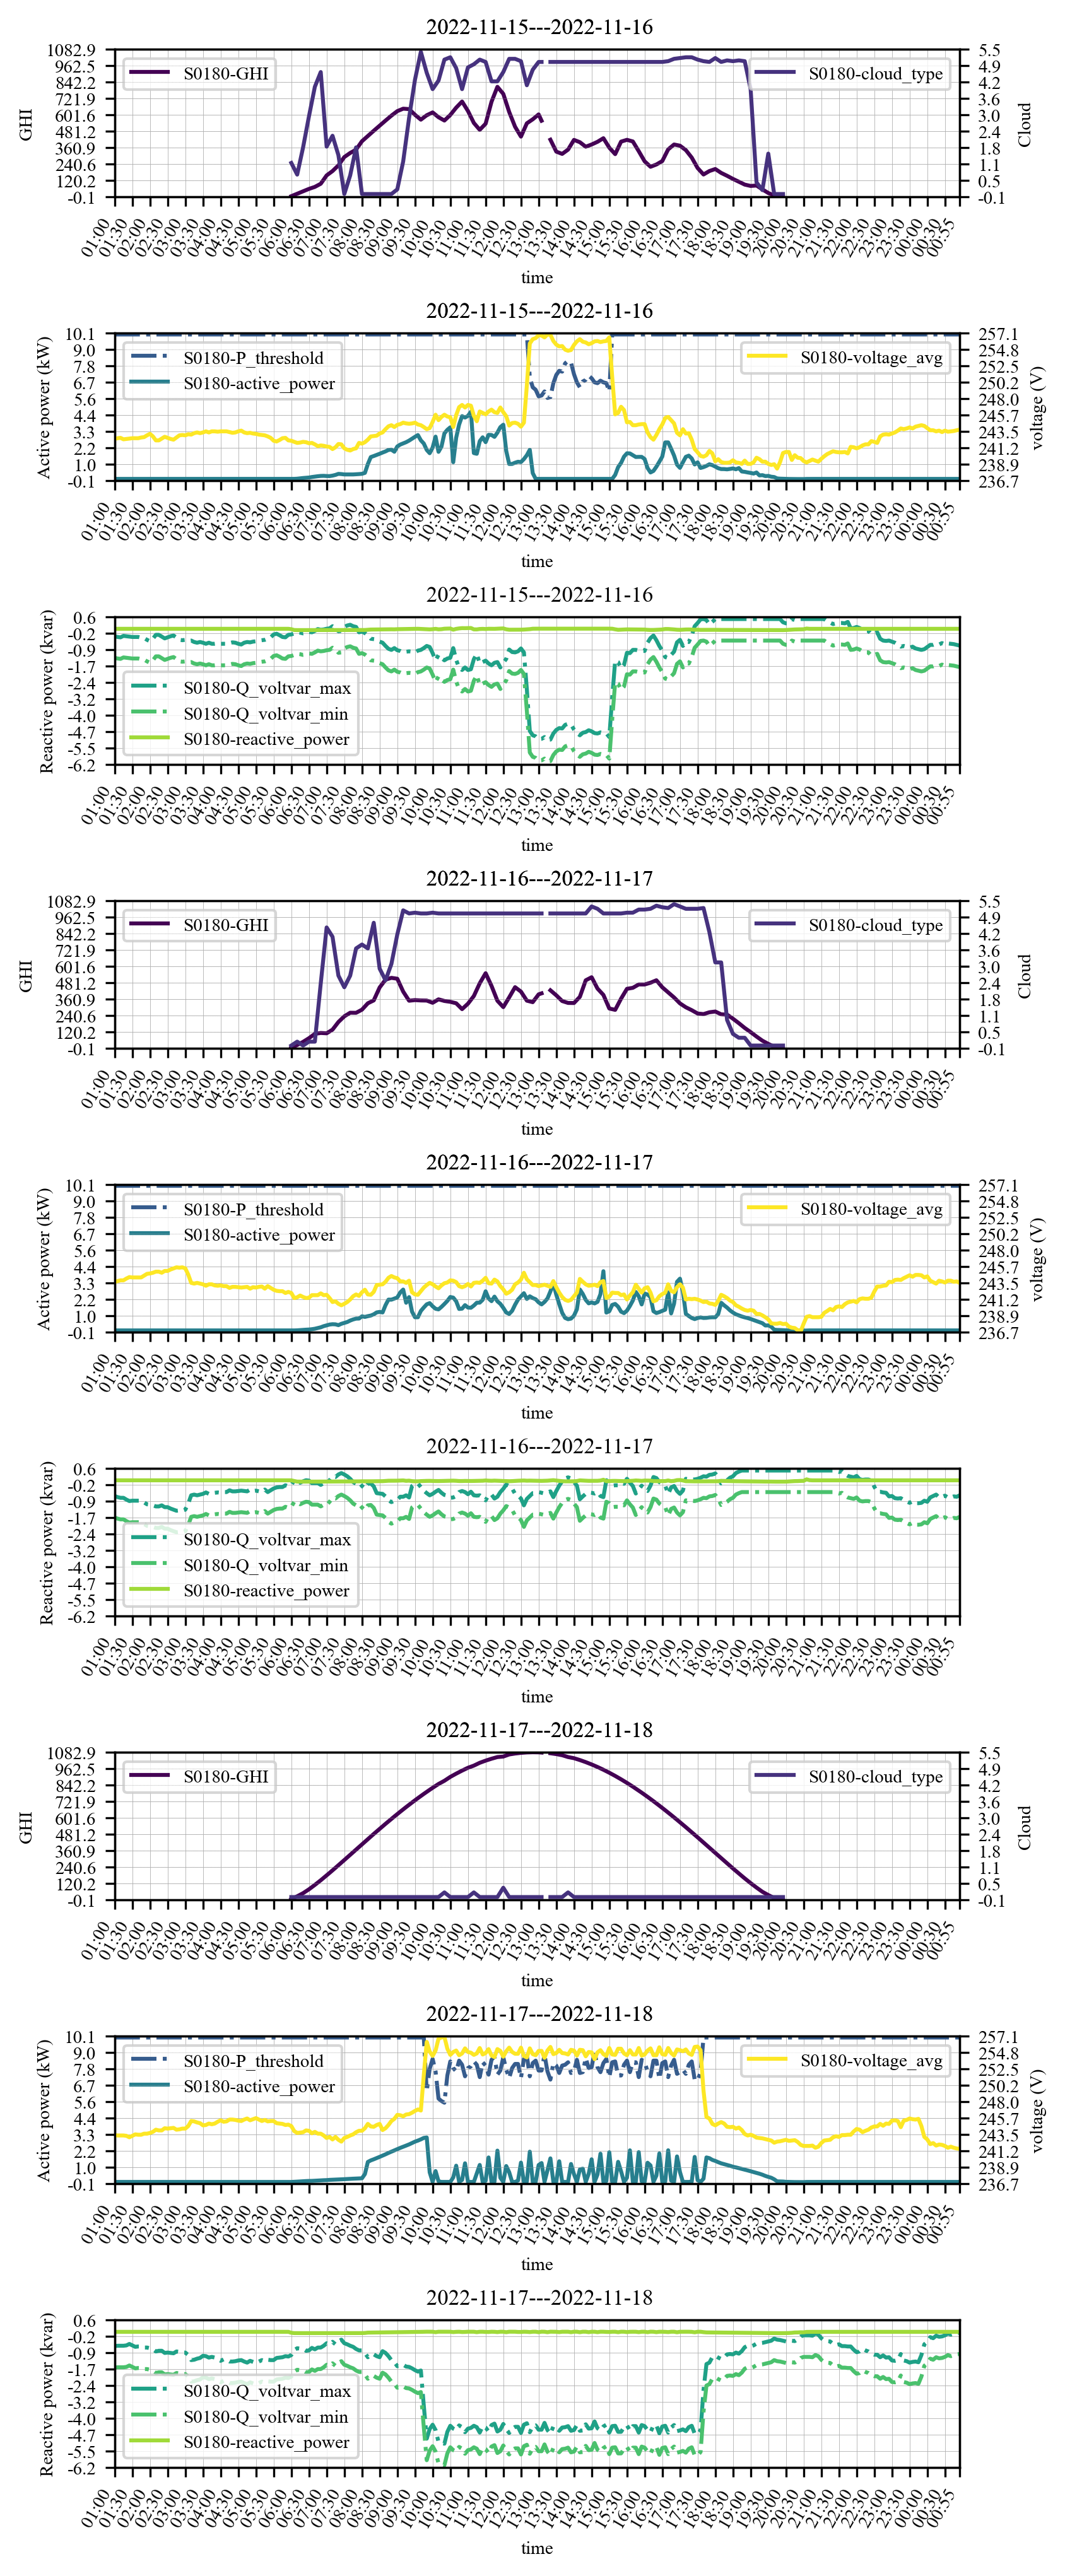

In [62]:
df8 = df5.copy()
df8 = df8[df8['edp_site_id'].isin(df8['edp_site_id'].unique()[ii:ii+1])].reset_index(drop=True)
df8 = df8.merge(solar, on=['time', 'postcode'], how='left')
df8 = df8.sort_values(['postcode', 'time']).groupby('postcode').apply(lambda group: group.set_index('time').interpolate(method='time', limit=1).reset_index()).reset_index(drop=True)
start_time = '2022-11-15 00:00:00+09:30' # In sydney local time
end_time = '2022-11-18 00:00:00+09:30' # In sydney local time
ii+=1

num_ticks = 24*2+1
# save_as = 'Figures/EDP_voltwatt_12Nov.jpeg'
save_as = ''
x_label = 'time'
y_labels = ['GHI', 'Cloud', 
            'Active power (kW)', 'Active power (kW)',
            'Reactive power (kvar)', 'Reactive power (kvar)','Reactive power (kvar)', 'voltage (V)']

plt_config = {'GHI': [0, 0, '-', None, None],
              'cloud_type': [0, 1, '-', None, None],
              'P_threshold': [1, 0, '-.', None, None], 'active_power': [1, 0, '-', None, None],
'Q_voltvar_max': [2, 0, '-.', None, None], 'Q_voltvar_min': [2, 0, '-.', None, None], 'reactive_power': [2, 0, '-', None, None],
'voltage_avg': [1, 1, '-', None, None]
}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df8, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
          figsize=[14/2.54,1.5],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['upper left', 'upper right',  'upper left', 'upper right', 'lower left'], 
           x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
a.do()

In [30]:
ii=0

Volt-watt non-compliance
Time: 2022-11-17 11:50:00+09:30
site_id: S0061, postcode: 5089
saved as:  /home/hossein/CICCADA/tests/Figures/EDP_voltwatt_19Nov.jpeg


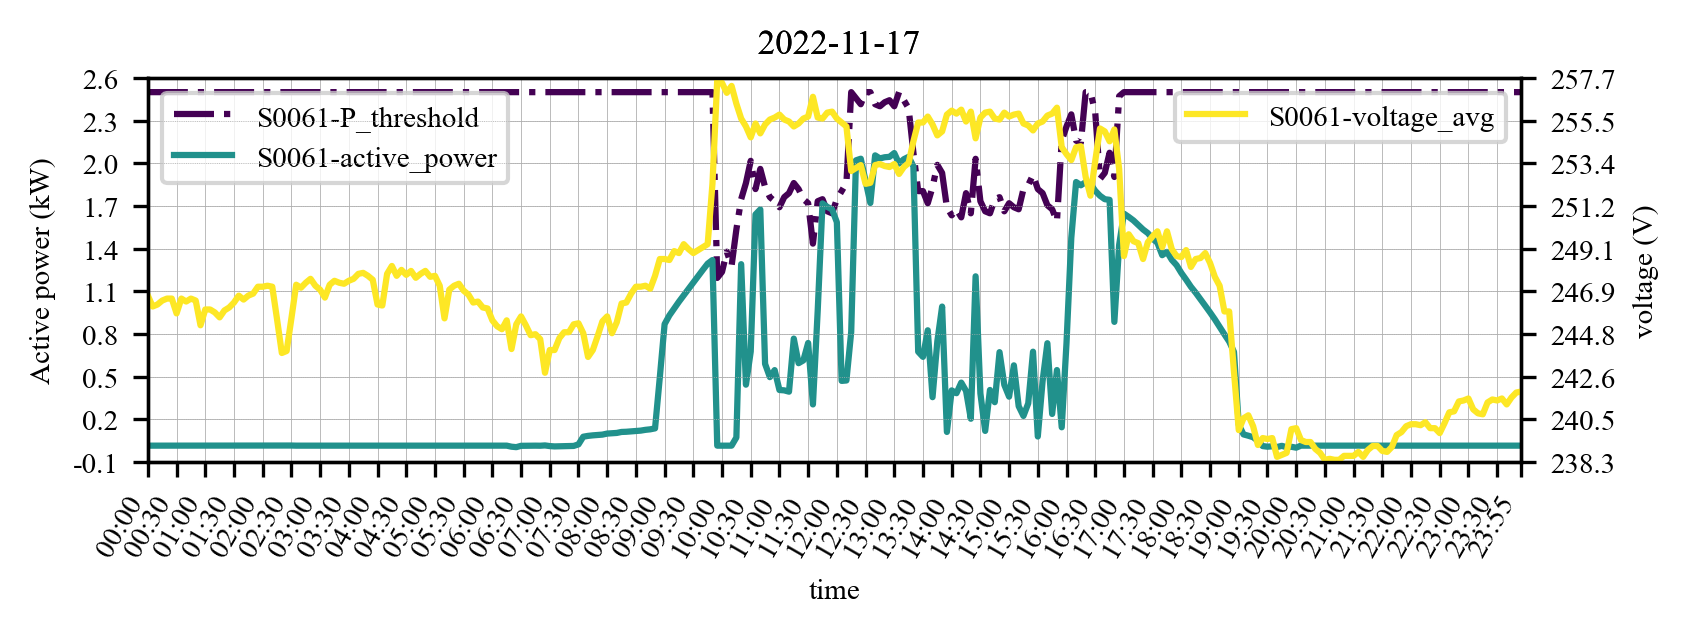

In [32]:
df8 = df5.query(f"P_noncomp > 0 and voltage_avg > 250").reset_index(drop=True)
site_ids = df8['edp_site_id'].unique()[0]
time_t = df8.query(f"edp_site_id == '{site_ids}'")['time'].to_list()[ii]
# ii+=1
t0 = time_t.replace(hour=0, minute=0, second=0, microsecond=0)
t1 = t0 + pd.Timedelta(days=1)
print(f"Volt-watt non-compliance")
print(f"Time: {time_t}")
print(f"site_id: {site_ids}, postcode: {df8['postcode'].unique()[0]}")
df8 = df5.copy()
df8 = df8[df8['edp_site_id'] == site_ids].reset_index(drop=True)
start_time = t0 # In sydney local time
end_time = t1 # In sydney local time


num_ticks = 24*2+1
save_as = 'Figures/EDP_voltwatt_19Nov.jpeg'
x_label = 'time'
y_labels = ['Active power (kW)', 'Active power (kW)', 'voltage (V)']
plt_config = {'P_threshold': [0, 0, '-.', None, None], 'active_power': [0, 0, '-', None, None],
'voltage_avg': [0, 1, '-', None, None]}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df8, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
          figsize=[14/2.54,2],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['upper left', 'upper right',  'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
a.do()

In [20]:
ii=0

Volt-var non-compliance
Time: 2022-11-13 11:40:00+10:30
site_id: S0150, postcode: 5035
saved as:  /home/hossein/CICCADA/tests/Figures/EDP_voltvar_19Nov.jpeg


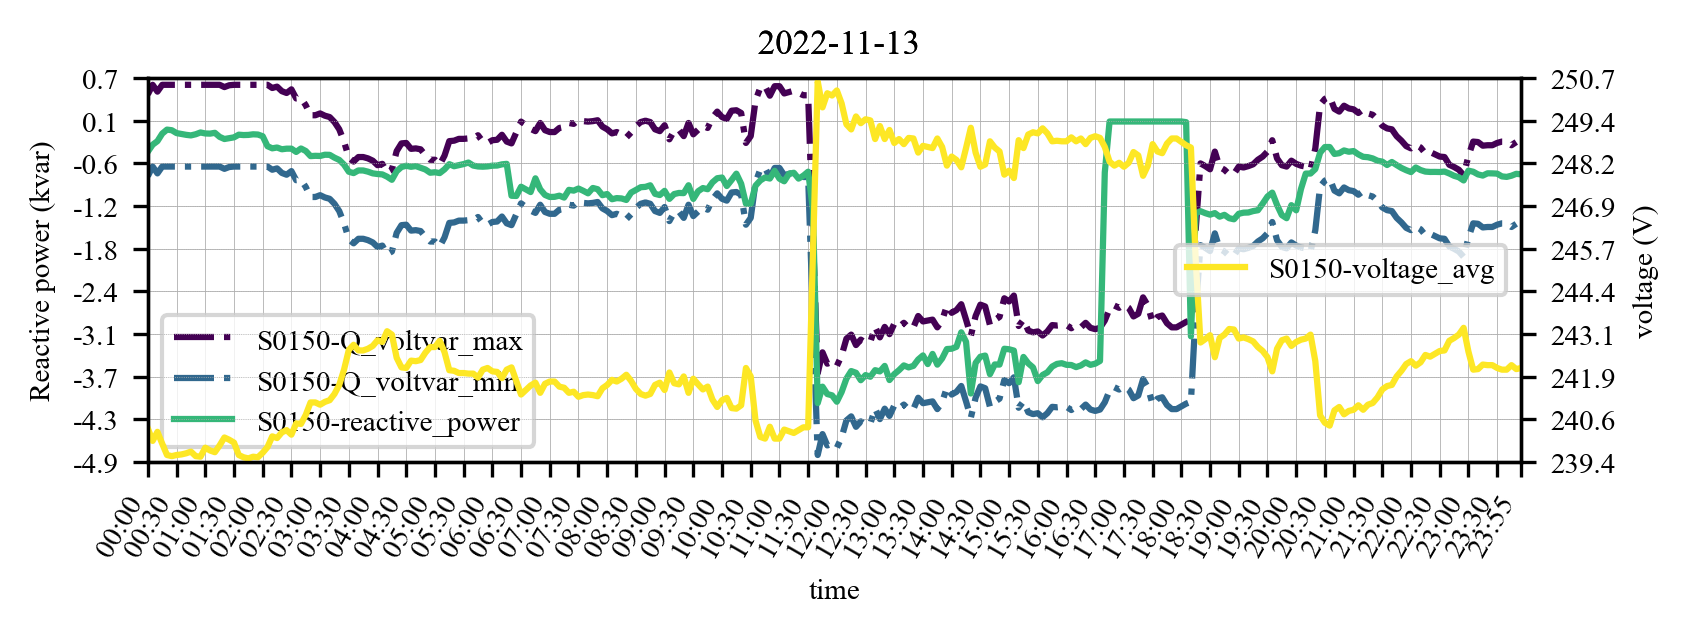

In [21]:
df8 = df5.query(f"Q_noncomp > .2 and voltage_avg > 250 and reactive_power < -.5").reset_index(drop=True)
site_ids = df8['edp_site_id'].unique()[0]
time_t = df8.query(f"edp_site_id == '{site_ids}'")['time'].to_list()[ii]
ii+=1
t0 = time_t.replace(hour=0, minute=0, second=0, microsecond=0)
t1 = t0 + pd.Timedelta(days=1)
print(f"Volt-var non-compliance")
print(f"Time: {time_t}")
print(f"site_id: {site_ids}, postcode: {df8['postcode'].unique()[0]}")
df8 = df5.copy()
df8 = df8[df8['edp_site_id'] == site_ids].reset_index(drop=True)
start_time = t0 # In sydney local time
end_time = t1 # In sydney local time


num_ticks = 24*2+1
save_as = 'Figures/EDP_voltvar_19Nov.jpeg'
x_label = 'time'
y_labels = ['Reactive power (kvar)', 'Reactive power (kvar)','Reactive power (kvar)', 'voltage (V)']
plt_config = {'Q_voltvar_max': [0, 0, '-.', None, None], 'Q_voltvar_min': [0, 0, '-.', None, None], 'reactive_power': [0, 0, '-', None, None],
'voltage_avg': [0, 1, '-', None, None]}

color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.1f'
a=my_plot4(start_time, end_time, df8, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='viridis',
          figsize=[14/2.54,2],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=10, dpi=300,  x_format= '%H:%M', 
           legend_loc=['lower left', 'center right',  'upper right'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, title_i=0, only1title=0)
a.do()

saved as:  /home/hossein/CICCADA/tests/Figures/Solar_clouds_active_power.jpeg


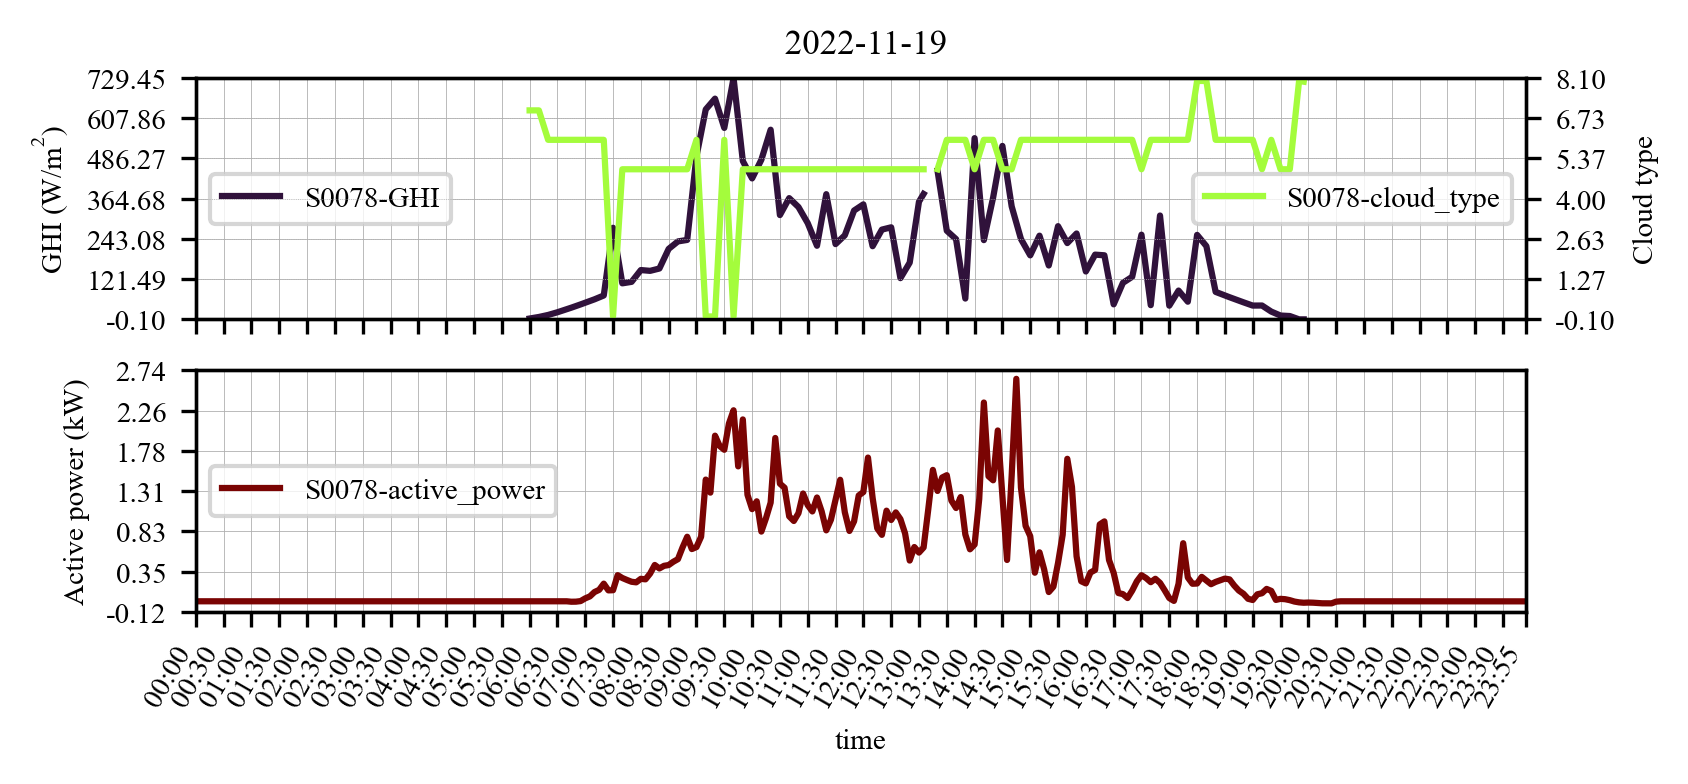

In [ ]:
df8 = df5.copy()
df8 = df8[df8['edp_site_id'].isin(df8['edp_site_id'].unique()[2:3])]
df8 = df8.merge(solar, on=['time', 'postcode'], how='left')
df8 = df8.sort_values(['postcode', 'time']).groupby('postcode').apply(lambda group: group.set_index('time').interpolate(method='time', limit=1).reset_index()).reset_index(drop=True)

start_time = '2022-11-19 00:00:00+1030' # In sydney local time
end_time = '2022-11-20 00:00:00+1030' # In sydney local time

num_ticks = 2*24+1
save_as = 'Figures/Solar_clouds_active_power19Nov.jpeg'
x_label = 'time'
y_labels = [
             'GHI ($\mathdefault{W/m^2}$)', \
            'Cloud type',
            'Active power (kW)', ]
plt_config = {
              'GHI': [0, 0, '-', None, None],
              'cloud_type': [0, 1, '-', None, None],
              # 'DNI': [0, 0, '-', None, None],
              'active_power': [1, 0, '-', None, None],
                }
color_nights=False
# color_by = 'group'
color_by = 'attribute'
ax_digit = '1.2f'
a=my_plot4(start_time, end_time, df8, plt_config=plt_config, ax_digit= ax_digit,
          group_attr='edp_site_id', time_attr='time', color_nights=color_nights,cmap='turbo',
          figsize=[14/2.54,1.25],  same_scale=1, fontsize=7, fontname='Times New Roman', plot_total=False, plot_total_func=['sum', [lambda x: max(x), 'max']], 
          num_ticks=num_ticks, num_yticks=7, dpi=300,  x_format= '%H:%M', 
          legend_loc=['center left', 'center right', 'center left'], x_label=x_label, y_labels=y_labels, color_by=color_by,
plot_period=np.timedelta64(1, 'D'), save_as=save_as, hspace=0,rotation = 60, step=0, gridwidth=[0.2, .2], legend_join='-', title='', legend_i=0, title_i=0, only1title=1, onlyntime=1)
a.do()